In [1]:
import torch, transformers, datasets

/Users/timbarvenov/Documents/uam/sem1/uczenie_glebokie_all/uczenie_glebokie/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
dataset = datasets.load_dataset("dair-ai/emotion", "split")

# Everything for model training (before Evaluation section) is the same as in prev lab

In [3]:
seed = 42

In [9]:
dataset = datasets.DatasetDict({
    "train": dataset["train"].shuffle(seed=seed).select(range(16000)),
    "validation": dataset["validation"].shuffle(seed=seed).select(range(2000)),
    "test": dataset["test"].shuffle(seed=seed).select(range(2000))
})

In [11]:
for split in ["train", "validation", "test"]:
    print(f"\n=== {split.upper()} SAMPLE ===")
    print(dataset[split][0])


=== TRAIN SAMPLE ===
{'text': 'while cycling in the country', 'label': 4}

=== VALIDATION SAMPLE ===
{'text': 'i usually increase the font and maybe if i am feeling brave change to a non standard font style', 'label': 1}

=== TEST SAMPLE ===
{'text': 'i was feeling really troubled and down over what my dad said', 'label': 0}


In [12]:
pretrained_name = "bert-base-uncased"
tokenizer = transformers.BertTokenizerFast.from_pretrained(pretrained_name)

In [13]:
MAX_LEN = 128

In [14]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

In [15]:
dataset = dataset.map(tokenize_batch, batched=True)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 25975.35 examples/s]


In [16]:
columns = ["input_ids", "attention_mask", "label"]

for split in ["train", "validation", "test"]:
    dataset[split].set_format(type="torch", columns=columns)

In [17]:
train_loader = torch.utils.data.DataLoader(dataset["train"], batch_size=8, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset["validation"], batch_size=16)
test_loader = torch.utils.data.DataLoader(dataset["test"], batch_size=16)

In [18]:
from tqdm.auto import tqdm
import os

In [19]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            optimizer.zero_grad()
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits
            total_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(logits, dim=-1).long()
            total_correct += (preds == labels.long()).sum().item()
            total += input_ids.size(0)
    avg_loss = total_loss / total
    acc = total_correct / total
    return avg_loss, acc


def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total = 0

    for batch in tqdm(dataloader, desc="train"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        # optional grad clipping
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        total += 1
    return total_loss / total

In [20]:
num_classes = 6

In [21]:
model = transformers.BertForSequenceClassification.from_pretrained(
    pretrained_name,
    num_labels=num_classes
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
device = torch.device("mps")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [23]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [24]:
num_epochs = 5
num_training_steps = num_epochs * len(train_loader)
num_warmup_steps = int(0.1 * num_training_steps)

In [25]:
scheduler = transformers.get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [26]:
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}
ckpt_dir = "checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, device)
    # scheduler.step(val_acc)  # LR scheduler keyed on val_acc

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        ckpt_path = os.path.join(ckpt_dir, f"best_model.pt")
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc,
        }, ckpt_path)
        print("Saved new best checkpoint:", ckpt_path)

evaluating: 100%|██████████| 125/125 [00:13<00:00,  9.08it/s]


Epoch 1: train_loss=0.6718, val_loss=0.1872, val_acc=0.9270
Saved new best checkpoint: checkpoints/best_model.pt


evaluating: 100%|██████████| 125/125 [00:13<00:00,  9.13it/s]


Epoch 2: train_loss=0.1332, val_loss=0.1237, val_acc=0.9380
Saved new best checkpoint: checkpoints/best_model.pt


evaluating: 100%|██████████| 125/125 [00:13<00:00,  9.32it/s]


Epoch 3: train_loss=0.0945, val_loss=0.1127, val_acc=0.9420
Saved new best checkpoint: checkpoints/best_model.pt


evaluating: 100%|██████████| 125/125 [00:13<00:00,  9.34it/s]


Epoch 4: train_loss=0.0749, val_loss=0.1279, val_acc=0.9460
Saved new best checkpoint: checkpoints/best_model.pt


evaluating: 100%|██████████| 125/125 [00:13<00:00,  9.33it/s]

Epoch 5: train_loss=0.0571, val_loss=0.1319, val_acc=0.9385


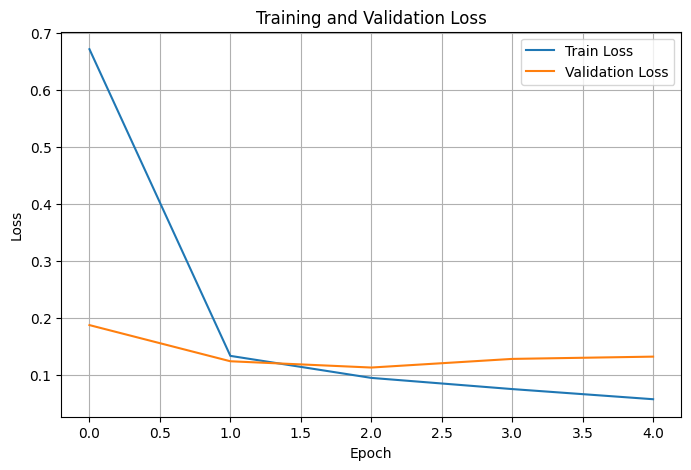

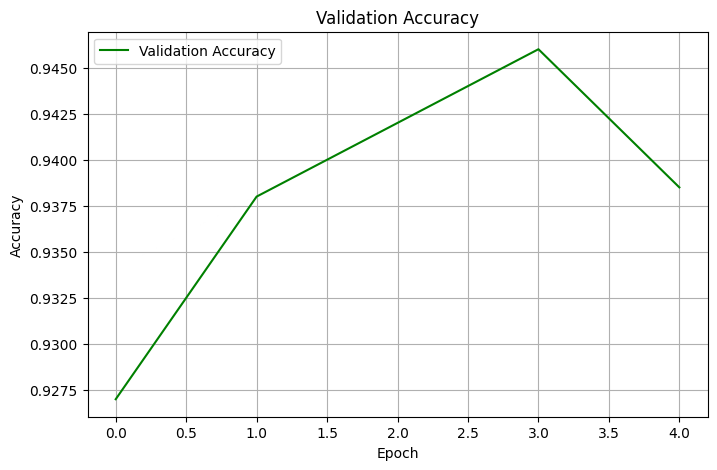

In [27]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history["val_acc"], label="Validation Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
checkpoint = torch.load(ckpt_path, map_location=device)

# Restore model and optimizer state
model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

# Optionally restore epoch and val_acc
start_epoch = checkpoint["epoch"]
best_val_acc = checkpoint["val_acc"]

print(f"Loaded checkpoint from epoch {start_epoch} with val_acc={best_val_acc:.4f}")

Loaded checkpoint from epoch 4 with val_acc=0.9460


# Evaluation

In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

In [39]:
def calculate_all_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            logits = outputs.logits

            preds = torch.argmax(logits, dim=-1).long()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


def decode_input(input_ids, tokenizer):
    return tokenizer.decode(input_ids, skip_special_tokens=True)

In [40]:
all_labels, model_preds = calculate_all_predictions(model, test_loader, device)

random_preds = np.random.randint(0, num_classes, size=len(all_labels))

evaluating: 100%|██████████| 125/125 [00:14<00:00,  8.76it/s]


In [43]:
model_total_correct = (model_preds == all_labels).sum()
rand_total_correct = (random_preds == all_labels).sum()

In [50]:
def evaluate_model(true_labels, predicted_labels, num_classes):
    cm = confusion_matrix(true_labels, predicted_labels, labels=list(range(num_classes)))
    acc = accuracy_score(true_labels, predicted_labels)
    # average=None returns metrics for each class
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, labels=list(range(num_classes)), average=None)

    print(f"confusion matrix:\n {cm}")
    print(f"accuracy: {acc}")
    print(f"precision: {precision}")
    print(f"recall: {recall}")
    print(f"f1: {f1}")

    for avg in ["micro", "macro", "weighted"]:
        p, r, f, _ = precision_recall_fscore_support(
            true_labels, predicted_labels, labels=list(range(num_classes)), average=avg
        )
        print(f"{avg} average: precision={p}, recall={r}, f1={f}")

In [51]:
print(f"======= Trained model evaluation =======")
evaluate_model(all_labels, model_preds, num_classes)

print(f"======= Random  model evaluation =======")
evaluate_model(all_labels, random_preds, num_classes)

======= Trained model evaluation =======
confusion matrix:
 [[567   2   0  10   2   0]
 [  0 653  32   3   0   7]
 [  0  23 135   1   0   0]
 [ 10   2   0 254   9   0]
 [  4   0   0   5 215   0]
 [  2   2   0   0  19  43]]
accuracy: 0.9335
precision: [0.97255575 0.95747801 0.80838323 0.93040293 0.87755102 0.86      ]
recall: [0.97590361 0.93956835 0.8490566  0.92363636 0.95982143 0.65151515]
f1: [0.9742268  0.94843863 0.82822086 0.9270073  0.91684435 0.74137931]
micro average: precision=0.9335, recall=0.9335, f1=0.9335
macro average: precision=0.9010618227249639, recall=0.8832502512130169, f1=0.889352876171272
weighted average: precision=0.9341136355739681, recall=0.9335, f1=0.9330544584981579
======= Random  model evaluation =======
confusion matrix:
 [[106  97 105  85  96  92]
 [117 111 111 118 113 125]
 [ 21  25  22  30  33  28]
 [ 57  38  33  55  46  46]
 [ 39  42  36  40  32  35]
 [ 10   9  12  13  20   2]]
accuracy: 0.164
precision: [0.30285714 0.3447205  0.06896552 0.16129032 0.

### Analiza + Podsumowanie

**Accuracy:**
- pokazuje przewagę wytrenowanego modelu, jednak może być mylące przy niezbalansowanych klasach jak w naszym datasecie

**Precision:**
- Model trenowany: wysokie dla wszystkich klas, szczególnie dla największych klas 1 i 2 (> 0.95)
- Model losowy: metryki są nizkie, dla klasy 6 aż 0.006, bo ta klasa jest bardzo nieliczna

**Recall:**
- Model trenowany: troche gorzej dla klas 3, 6

**F1 dla modelu trenowanego:**
- dla najliczniejszych klas pokazuje lepsze wyniki
- macro=0.89 < micro = 0.93 pokazuje, jak model radzi sobie z rzadkimi klasami. Rzadkie klasy są trudniejsze dla tego modelu.

**Macierz pomyłek:**
- Model trenowany: dobra przekątna o wysokich wartościach pokazuję, że model poprawnie rozpoznaje większość przypadków.
- Losowy: wartości rozproszone po macierzy, bo jest losowy i nie ma zdolności rozpoznawania klas

Model losowy pokazuje coraz gorsze wyniki dla mniej licznych klas, co jest całkiem oczekiwane